In [49]:
%matplotlib widget
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd


In [50]:
df = pd.read_csv('/Users/mrvarshney/Codes/ARIES/star_files_3_dat/Final_1731_Photometry.dat', delimiter = '\t')
time = df['JD']
flux = 10**(-0.4 * df['Differential_Magnitude'])
flux_err = 10**(-0.4 * df['Differential_Error'])

lc = lk.LightCurve(time = time, flux = flux, flux_err=flux_err).normalize()

(0.5, 1.5)

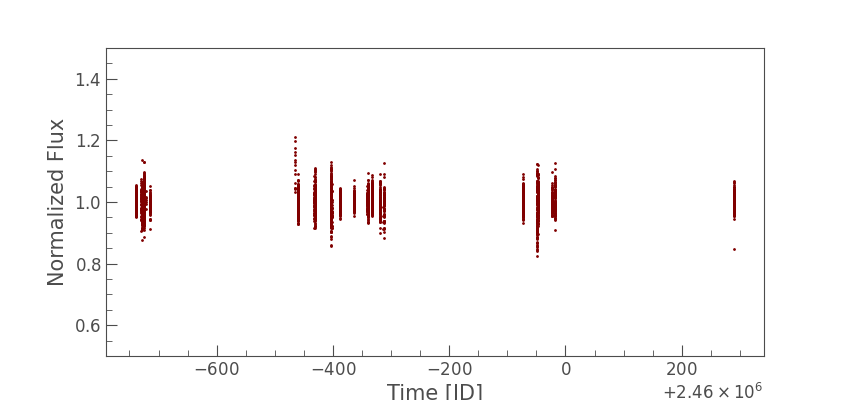

In [51]:
lc.plot(color = 'maroon', marker = '.', lw = 0)
plt.ylim(0.5,1.5)

`period` contains 6399713 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

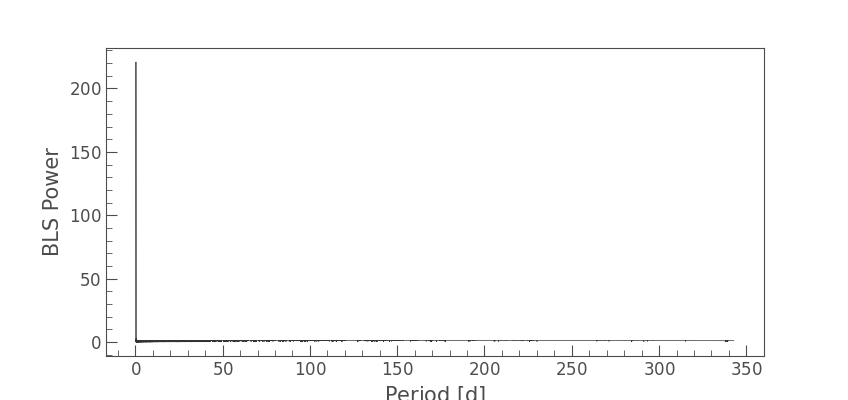

In [52]:
pg = lc.to_periodogram(method='boxleastsquares')
pg.plot()

In [53]:
best_period = pg.period_at_max_power
print(best_period)

0.3302931370497363 d


<Axes: xlabel='Phase (Normalized)', ylabel='Normalized Flux'>

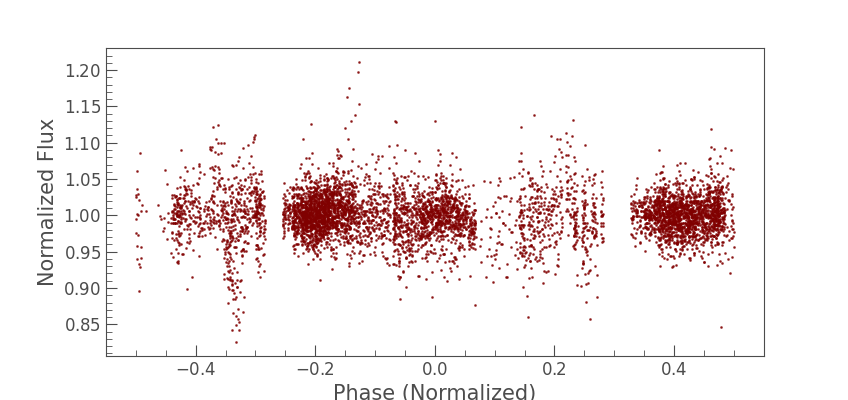

In [54]:
import astropy.units as u

lc_phased = lc.fold(1.098107856771566, normalize_phase=True)
lc_phased.plot(linewidth =0, color = 'maroon', marker = '.', alpha=0.7)

(0.8, 1.1)

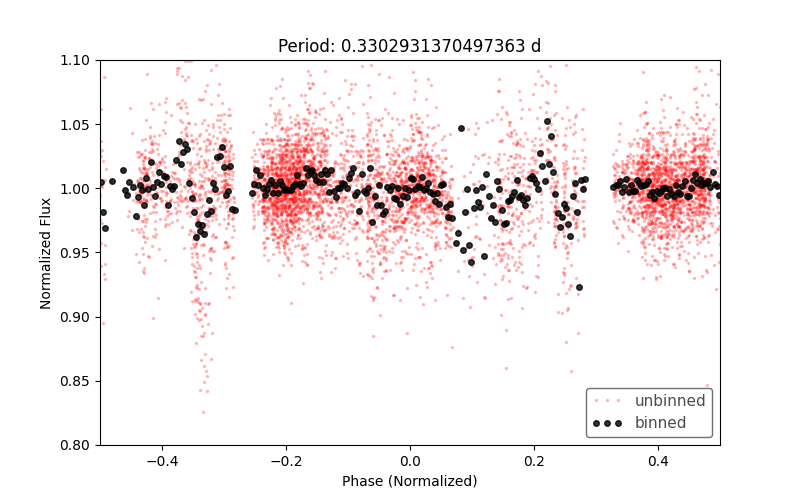

In [55]:
lc_phased_binned = lc_phased.bin(5/60/24)
fig, ax = plt.subplots(figsize = (8,5))

lc_phased.plot(ax = ax, marker = '.', linewidth = 0, color = 'red', alpha = 0.2, markersize = 3, label = 'unbinned')
lc_phased_binned.plot(ax = ax, marker = 'o', linewidth = 0, color = 'k', alpha = 0.8, markersize = 4, label = 'binned')

# set x and y axis limits (for different targets these limits will be different!)
plt.xlim(-0.5,0.5)
plt.title(f"Period: {best_period}")
plt.ylim(0.8,1.1)

In [56]:
pg.compute_stats()

No period specified. Using period at max power
No duration specified. Using duration at max power
No transit time specified. Using transit time at max power


{'transit_times': <Time object: scale='tdb' format='jd' value=[2459260.99477586 2459261.325069   2459261.65536214 ... 2460288.86701836
  2460289.1973115  2460289.52760464]>,
 'per_transit_count': array([225, 142,   0, ...,   0, 143, 530], shape=(3115,)),
 'per_transit_log_likelihood': array([-0.0114221 ,  0.0384012 ,  0.        , ...,  0.        ,
        -0.00208658,  0.01317813], shape=(3115,)),
 'depth': (<Quantity 0.00493185>, <Quantity 0.16608922>),
 'depth_phased': (<Quantity 0.>, <Quantity inf>),
 'depth_half': (<Quantity 0.>, <Quantity inf>),
 'depth_odd': (<Quantity 0.00488863>, <Quantity 0.16612394>),
 'depth_even': (<Quantity 0.00506269>, <Quantity 0.16640714>),
 'harmonic_amplitude': <Quantity 0.00268122>,
 'harmonic_delta_log_likelihood': np.float64(0.0467874384156417)}